# 📊 Cyber Square Institute  - Staff Schedule Analysis 

This analysis focuses on evaluating trainer scheduling efficiency, workload distribution, and resource utilization.

### Objectives:
- Analyze daily and weekly workload distribution
- Identify overutilized and underutilized trainers
- Evaluate time slot utilization efficiency
- Detect workload imbalance across courses
- Provide actionable recommendations for schedule optimization

## 📁 Dataset
- File: `staff_schedule_with_weekly.csv`

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px



In [5]:
df = pd.read_csv(r"C:\Users\Muhammed Sinan m\Documents\cs\python\project\datasets\staff_schedule_with_weekly.csv")
df

,staff_id,name,course,10:00-12:00,12:00-02:00,02:30-04:30,04:30-05:30 (Online),daily_hours,weekly_hours
0,TS001,Akhil Nair,Python Full Stack Development,Python-B3,Python-B2,Python-B1,Python-B1,7,35
1,TS002,Deepa R,Python Full Stack Development,Python-B4,Python-B3,Python-B2,Free Period,6,30
2,TS003,Kiran Kumar,Data Science with Python,DS-B1,DS-B2,DS-B3,DS-B1,7,35
3,TS004,Anjali Menon,Data Science with Python,DS-B4,DS-B5,DS-B6,Free Period,6,30
4,TS005,Sneha Pillai,React Frontend Developer,React-B1,React-B2,React-B3,Free Period,6,30
5,TS006,Anu George,MERN Stack Development,MERN-B1,MERN-B2,MERN-B3,Free Period,6,30
6,TS007,Farhan Ali,DevOps,DevOps-B1,Free Period,DevOps-B2,DevOps-B3,5,25
7,TS008,Nithya S,Cyber Security,Cyber-B1,Cyber-B2,Cyber-B3,Free Period,6,30
8,TS009,Vivek Raj,Business Analytics,BA-B1,Free Period,BA-B2,BA-B3,5,25
9,TS010,Meera Joseph,Flutter Development,Flutter-B2,Free Period,Flutter-B1,Free Period,4,20


## Data Overview

### Dataset Features:
- Trainer Name
- Daily Hours
- Weekly Hours
- Course
- Time Slots
- Free Periods

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   staff_id              11 non-null     str  
 1   name                  11 non-null     str  
 2   course                11 non-null     str  
 3   10:00-12:00           11 non-null     str  
 4   12:00-02:00           11 non-null     str  
 5   02:30-04:30           11 non-null     str  
 6   04:30-05:30 (Online)  11 non-null     str  
 7   daily_hours           11 non-null     int64
 8   weekly_hours          11 non-null     int64
dtypes: int64(2), str(7)
memory usage: 1.6 KB


In [11]:
df.describe()

,daily_hours,weekly_hours
count,11.000000,11.000000
mean,5.636364,28.181818
std,1.026911,5.134553
min,4.000000,20.000000
25%,5.000000,25.000000
50%,6.000000,30.000000
75%,6.000000,30.000000
max,7.000000,35.000000


## Core Analysis

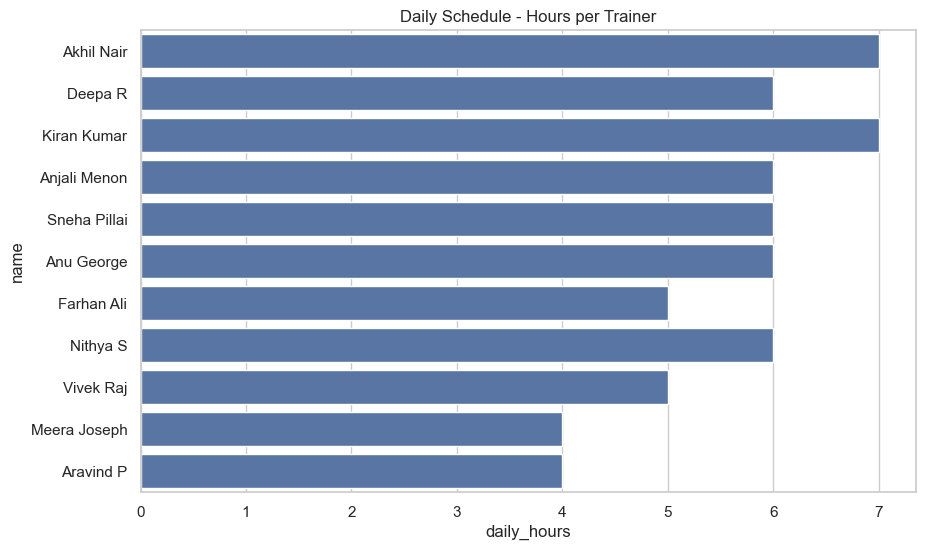

In [16]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="daily_hours",
    y="name"
)

plt.title("Daily Schedule - Hours per Trainer")
plt.show()

### Key Insight: Workload Imbalance and Capacity Compression

The majority of trainers operate at 6–7 hours per day, indicating that the system is functioning close to its maximum capacity.

At the same time, a subset of trainers remains underutilized (4–5 hours), revealing inefficient workload distribution.

This imbalance suggests that scheduling decisions are not optimized across available resources, leading to:
- Increased burnout risk for heavily loaded trainers
- Underutilization of available capacity
- Reduced operational efficiency

The system currently prioritizes assignment convenience over balanced workload allocation.

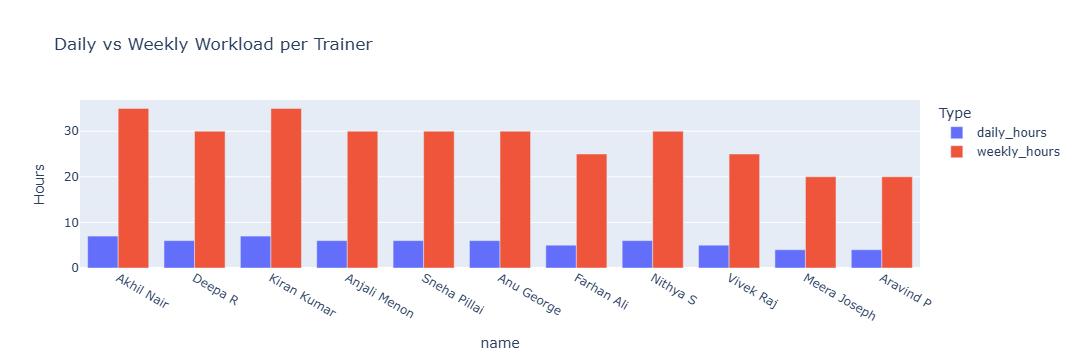

In [28]:
fig = px.bar(
    df_melted,
    x="name",
    y="Hours",
    color="Type",
    barmode="group",
    title="Daily vs Weekly Workload per Trainer"
)

fig.show()

### Key Insight: Rigid Workload Structuring with Imbalance Across Trainers

The comparison of daily and weekly workload reveals a perfectly proportional relationship, where weekly hours are consistently five times the daily hours for all trainers.

While this indicates scheduling consistency, it also exposes a lack of flexibility in workload allocation.

Two critical patterns emerge:

- **Workload Clustering**: Trainers are grouped into fixed workload bands (4h, 5h, 6h, 7h per day), rather than a smooth distribution. This suggests that scheduling is done using predefined blocks instead of adaptive allocation.

- **Imbalance in Resource Utilization**:  
  A significant portion of trainers operate at higher workload levels (6–7 hours/day), while others remain underutilized (4–5 hours/day).  
  This creates a gap of up to 75% between the least and most utilized trainers.

- **Lack of Dynamic Scheduling**:  
  All trainers follow identical daily patterns throughout the week, indicating no adjustment based on demand fluctuations, trainer availability, or course requirements.

Overall, the system prioritizes consistency over optimization, leading to:
- Potential burnout risk for highly utilized trainers  
- Inefficient use of available capacity  
- Limited ability to respond to changing workload demands  

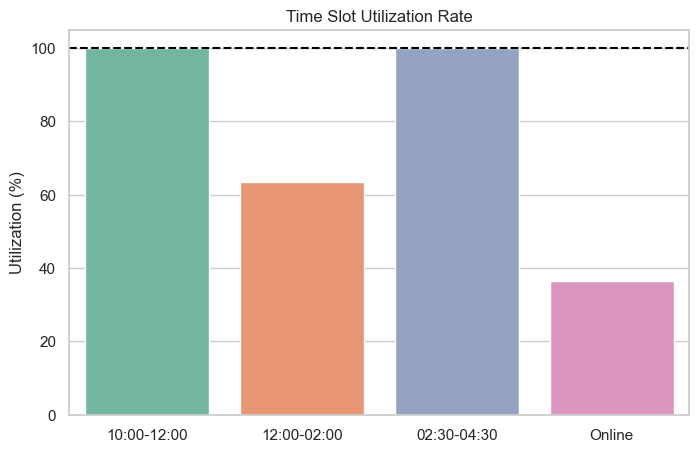

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=slots,
    y=utilization,
    hue=slots,           
    palette="Set2",       
)

plt.axhline(100, linestyle='--', color='black')
plt.title("Time Slot Utilization Rate")
plt.ylabel("Utilization (%)")

plt.show()

### Key Insight: Imbalanced Utilization Across Time Slots

The time slot utilization pattern highlights a clear imbalance in how scheduling capacity is used throughout the day.

Two slots (10:00–12:00 and 02:30–04:30) are fully utilized, indicating strong demand concentration during these periods. While this reflects efficient usage, it also creates a bottleneck where no additional sessions can be accommodated.

The 12:00–02:00 slot shows moderate utilization (~63%), suggesting that there is still room to redistribute workload from peak periods.

The most notable gap is in the online slot, which is significantly underutilized (~36%). This indicates that a substantial portion of available capacity is not being leveraged.

Overall, the scheduling system is skewed toward specific time windows rather than being evenly distributed, leading to:
- High pressure on peak slots
- Underuse of available alternatives
- Reduced overall scheduling efficiency

In [34]:
time_cols = [
    "10:00-12:00",
    "12:00-02:00",
    "02:30-04:30",
    "04:30-05:30 (Online)"
]

df["free_periods"] = df[time_cols].apply(
    lambda row: sum(row == "Free Period"),
    axis=1
)

df[["name", "free_periods"]]

,name,free_periods
0,Akhil Nair,0
1,Deepa R,1
2,Kiran Kumar,0
3,Anjali Menon,1
4,Sneha Pillai,1
5,Anu George,1
6,Farhan Ali,1
7,Nithya S,1
8,Vivek Raj,1
9,Meera Joseph,2


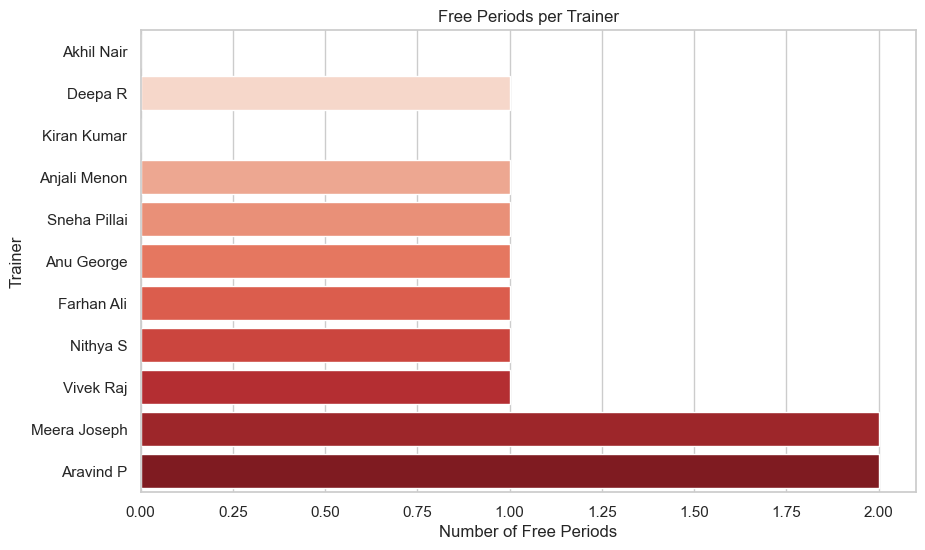

In [35]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="free_periods",
    y="name",
    hue="name",
    palette="Reds",
    legend=False
)

plt.title("Free Periods per Trainer")
plt.xlabel("Number of Free Periods")
plt.ylabel("Trainer")

plt.show()

### Key Insight: Imbalanced Utilization with Clear Idle Capacity

The distribution of free periods shows a noticeable imbalance in how trainer time is utilized.

A small group of trainers (Akhil Nair, Kiran Kumar) have no free periods, indicating they are fully occupied throughout the day. While this reflects high utilization, it also suggests limited flexibility and potential overload risk.

On the other end, trainers like Meera Joseph and Aravind P have two free periods, representing significant unused capacity. Several others fall in between with one free period.

This uneven distribution highlights that workload is not optimally balanced. Instead of evenly distributing sessions, the schedule concentrates work on certain trainers while leaving others partially idle.

Overall, this results in:
- Overutilization of some trainers
- Underutilization of available capacity
- Missed opportunities to redistribute workload efficiently

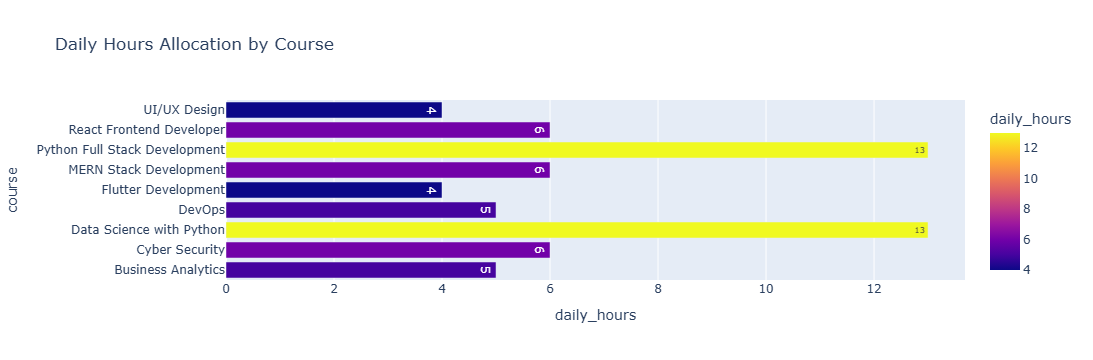

In [38]:
fig = px.bar(
    course_hours,
    x="daily_hours",
    y="course",
    color="daily_hours",
    title="Daily Hours Allocation by Course",
    text="daily_hours"
)

fig.show()

### Key Insight: Concentration of Workload in Core Courses

The allocation of daily hours across courses shows a clear concentration of workload in a few key programs.

Python Full Stack Development and Data Science with Python dominate the schedule, each accounting for the highest total daily hours. This indicates strong demand and priority allocation of training resources toward these courses.

In contrast, several other courses such as UI/UX Design and Flutter Development receive significantly fewer hours, reflecting lower demand or limited batch allocation.

This uneven distribution highlights a demand-driven scheduling pattern, where resources are heavily focused on core courses while others operate at a smaller scale.

From an operational perspective, this creates:
- Higher dependency on trainers handling high-demand courses  
- Increased pressure on specific course pipelines  
- Underutilization of capacity in lower-demand courses  

Overall, the system is efficient in meeting demand for major courses but lacks balance in resource distribution across the full course portfolio.

### Workload Balance Score

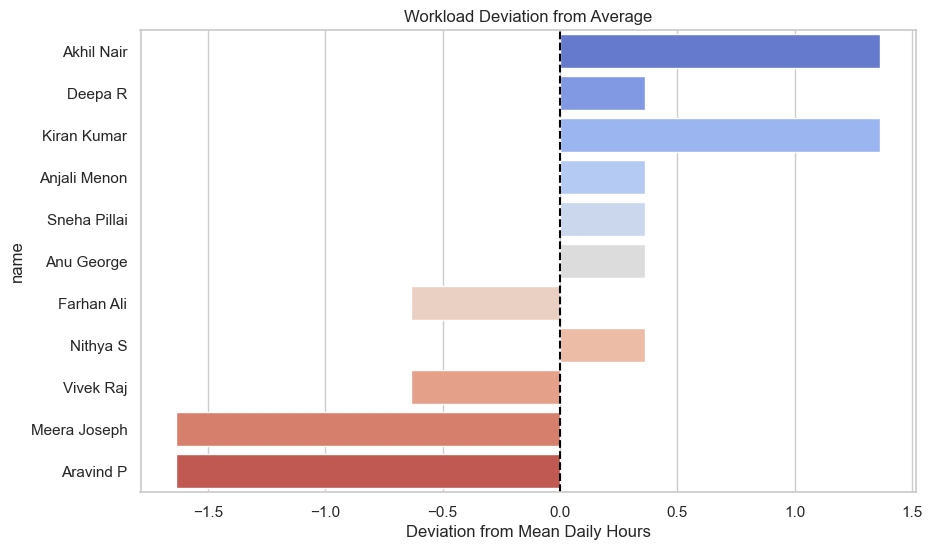

In [39]:
mean_hours = df["daily_hours"].mean()

df["deviation"] = df["daily_hours"] - mean_hours

plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="deviation",
    y="name",
    hue="name",
    palette="coolwarm",
    legend=False
)

plt.axvline(0, color='black', linestyle='--')
plt.title("Workload Deviation from Average")
plt.xlabel("Deviation from Mean Daily Hours")

plt.show()

# 📊 Final Insights

The staff schedule analysis reveals that while the system maintains structural consistency, it lacks optimization in workload distribution and resource utilization.

### 1. Workload Imbalance Across Trainers
The deviation analysis confirms that workload is not evenly distributed. A subset of trainers operates above the average workload, while others fall significantly below it. This imbalance leads to inefficient use of available capacity and increases pressure on highly utilized trainers.

### 2. Rigid Scheduling Structure
The relationship between daily and weekly hours follows a fixed pattern across all trainers, indicating a lack of flexibility. This rigidity prevents dynamic adjustment of schedules based on demand fluctuations or trainer availability.

### 3. Time Slot Imbalance
Peak time slots are fully utilized, while others—especially online sessions—remain underutilized. This uneven distribution creates bottlenecks during high-demand periods and leaves available capacity unused.

### 4. Uneven Allocation of Free Periods
Some trainers have no free periods, indicating full utilization and potential overload, while others have multiple free slots. This reflects poor workload balancing at the individual level.

### 5. Concentration of Workload in Core Courses
A significant portion of workload is concentrated in a few high-demand courses such as Python and Data Science. This creates dependency on specific trainers and limits scalability if demand increases further.

---

Overall, the system demonstrates operational consistency but lacks efficiency, flexibility, and balance in resource allocation.

## ✅ Recommendations

### 1. Redistribute Workload Across Trainers
Balance the workload by reallocating sessions from overutilized trainers to those with available capacity. Target a more uniform distribution around the average daily workload.

### 2. Introduce Flexible Scheduling
Move away from fixed daily patterns and allow variability in schedules based on demand. This will improve responsiveness and overall efficiency.

### 3. Optimize Time Slot Utilization
Shift some sessions from fully saturated slots to underutilized periods, particularly online slots, to reduce bottlenecks and improve capacity usage.

### 4. Balance Free Period Allocation
Ensure that no trainer is consistently overloaded or underutilized. Distribute free periods more evenly to improve both efficiency and sustainability.

### 5. Reduce Course Dependency Risk
Train or assign multiple trainers to high-demand courses to reduce reliance on a limited number of resources and improve scalability.

### 6. Leverage Underutilized Capacity
Actively utilize trainers with lower workload and available free periods to support high-demand areas or expand course offerings.

---

### Expected Impact
- Improved resource utilization  
- Reduced workload imbalance  
- Better scalability and flexibility  
- Enhanced operational efficiency  